In [1]:
%%capture
# Install dependencies

!pip uninstall -y torch torchtext torchvision torchaudio numpy scanpy

!pip install "numpy<2" -q
!pip install torch==2.2.2 torchvision==0.17.2 --index-url https://download.pytorch.org/whl/cu121 -q
!pip install --no-deps git+https://github.com/bowang-lab/scGPT.git -q
!pip install "scanpy==1.10.4" wandb -q
!pip install "numpy<2" --force-reinstall --no-deps -q
!pip install --force-reinstall --no-deps torchtext==0.17.2 -q
!pip install scikit-misc -q

print("Restart session")

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import confusion_matrix
import scanpy as sc

from google.colab import drive
drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/usr/local/lib/python3.12/dist-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.12/dist-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


                    Train  Test  Total
scGPT_target_label                    
T-Cells             17253  3855  21108
Ductal               7376  3742  11118
Fibroblasts          7689  2361  10050
Acinar               4438  3877   8315
Macrophages          4680  1514   6194
B-Cells              4172   239   4411
Endothelial          1793  1454   3247
Neutrophils          2187   181   2368
Stellate             1105   462   1567
Mast                  479   510    989
Plasma                557   151    708
Endocrine             251   156    407
NK                    377    28    405
Schwann               124    63    187


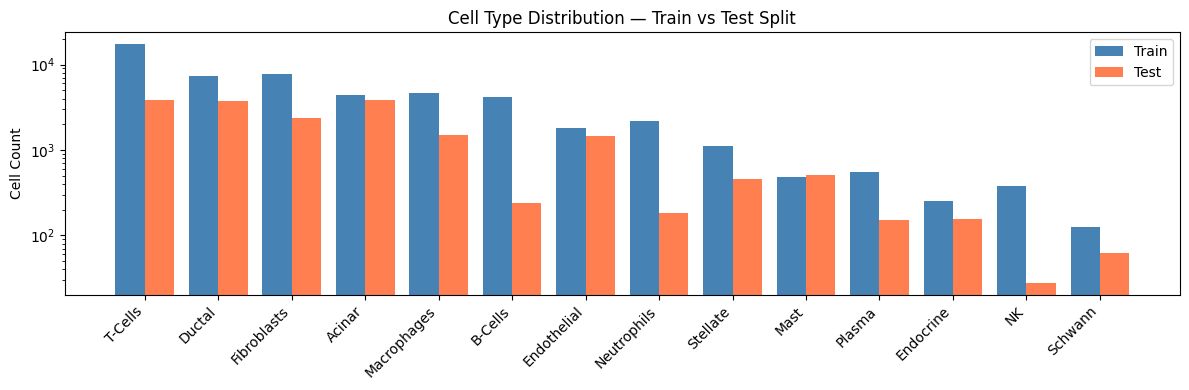

In [3]:
# Load the full annotated data
adata = sc.read_h5ad("/content/drive/MyDrive/PDAC_ADJ_Final_Annotated.h5ad")

# Recreate the same split
TEST_SAMPLES = ["ADJ4", "ADJ5", "PDAC1"]
TRAIN_SAMPLES = [s for s in adata.obs["sample_id"].unique() if s not in TEST_SAMPLES]

adata_train = adata[adata.obs["sample_id"].isin(TRAIN_SAMPLES)]
adata_test = adata[adata.obs["sample_id"].isin(TEST_SAMPLES)]

# Count cell types in each split
train_counts = adata_train.obs["scGPT_target_label"].value_counts().sort_index()
test_counts = adata_test.obs["scGPT_target_label"].value_counts().sort_index()

# Combine into a table
dist = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
}).fillna(0).astype(int)

dist["Total"] = dist["Train"] + dist["Test"]
dist = dist.sort_values("Total", ascending=False)

print(dist.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(dist))
width = 0.4

ax.bar([i - width / 2 for i in x], dist["Train"], width=width, label="Train", color="steelblue")
ax.bar([i + width / 2 for i in x], dist["Test"], width=width, label="Test", color="coral")

ax.set_xticks(list(x))
ax.set_xticklabels(dist.index, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Cell Count")
ax.set_title("Cell Type Distribution — Train vs Test Split")
ax.legend()
ax.set_yscale("log")  # log scale so rare types are visible

plt.tight_layout()
plt.show()

In [4]:
EVAL_DIR = "/content/drive/MyDrive/scGPT_human/finetuned_pdac/inference"
print("Contents:", os.listdir(EVAL_DIR))

Contents: ['umap_groundTruth.png', 'results.pkl', 'umap_predictions.png', 'evaluation_results.json', 'confusion_matrix.png', 'run.log', 'predictions.csv', 'confusion_matrix_clean.png', 'umap_comparison.png']


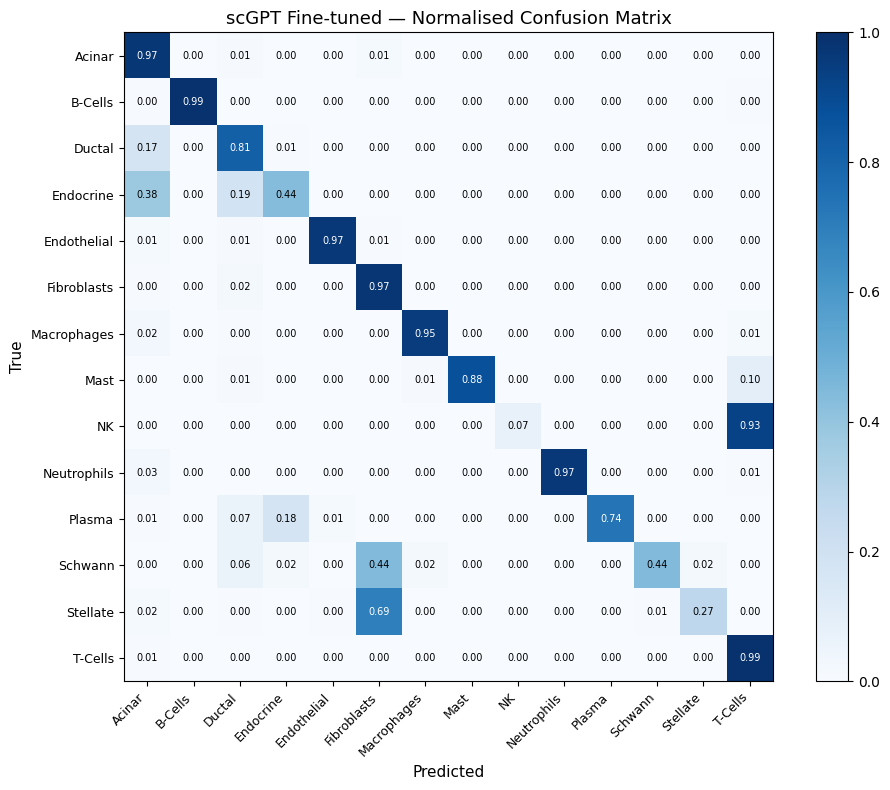

In [5]:
# Clean confusion matrix
df = pd.read_csv(f"{EVAL_DIR}/predictions.csv")

# Auto-detect true/pred columns
true_col = [c for c in df.columns if any(x in c.lower() for x in ["true", "label", "ground", "actual"])][0]
pred_col = [c for c in df.columns if "pred" in c.lower()][0]

labels = sorted(df[true_col].unique())
cm = confusion_matrix(df[true_col], df[pred_col], labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
ax.set_title("scGPT Fine-tuned — Normalised Confusion Matrix", fontsize=13)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = cm_norm[i, j]
        color = "white" if val > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)

plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/confusion_matrix_clean.png", dpi=150, bbox_inches="tight")
plt.show()



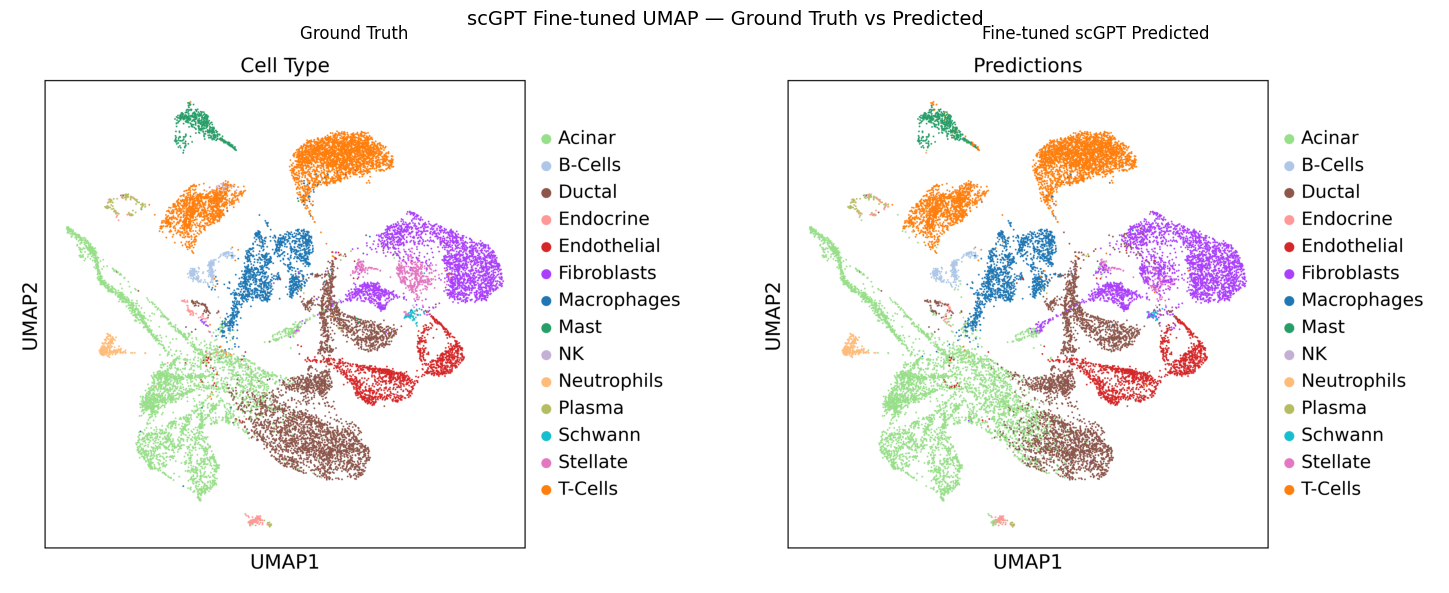

In [6]:
# UMAP ground truth vs predicted side by side
gt_path = f"{EVAL_DIR}/umap_groundTruth.png"
pred_path = f"{EVAL_DIR}/umap_predictions.png"

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("scGPT Fine-tuned UMAP — Ground Truth vs Predicted", fontsize=14)

for ax, path, title in zip(axes, [gt_path, pred_path], ["Ground Truth", "Fine-tuned scGPT Predicted"]):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/umap_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
df['sample_id'] = df['index'].str.split('_').str[-1]
df['condition'] = np.where(df['sample_id'].str.startswith('PDAC'), 'PDAC', 'ADJ')

/tmp/ipykernel_5619/2109679517.py:10: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
/tmp/ipykernel_5619/2109679517.py:10: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


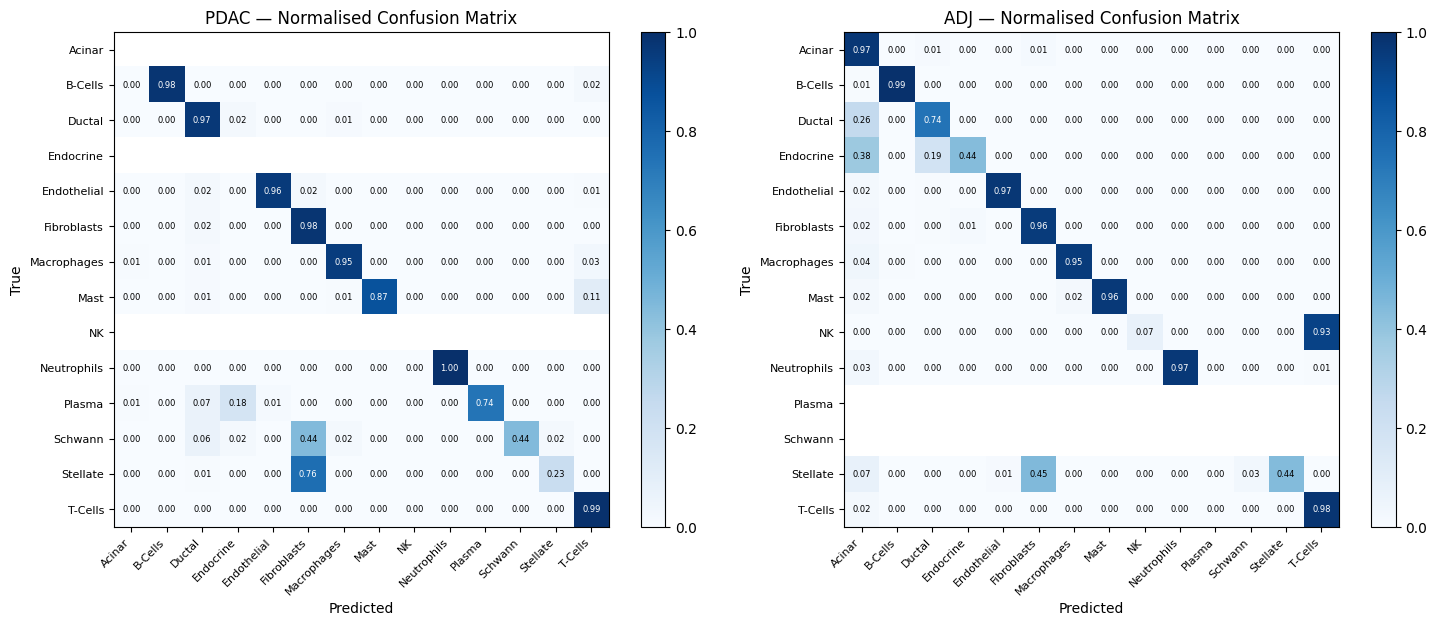

In [18]:
labels = sorted(df[true_col].unique())

df_pdac = df[df['condition'] == 'PDAC']
df_adj  = df[df['condition'] == 'ADJ']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, subset, title in zip(axes, [df_pdac, df_adj], ['PDAC', 'ADJ']):
    cm = confusion_matrix(subset[true_col], subset[pred_col], labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)

    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title} — Normalised Confusion Matrix', fontsize=12)

    for i in range(len(labels)):
        for j in range(len(labels)):
            val = cm_norm[i, j]
            if not np.isnan(val):
                ax.text(
                    j,
                    i,
                    f'{val:.2f}',
                    ha='center',
                    va='center',
                    fontsize=6,
                    color='white' if val > 0.5 else 'black'
                )

plt.tight_layout()
plt.show()

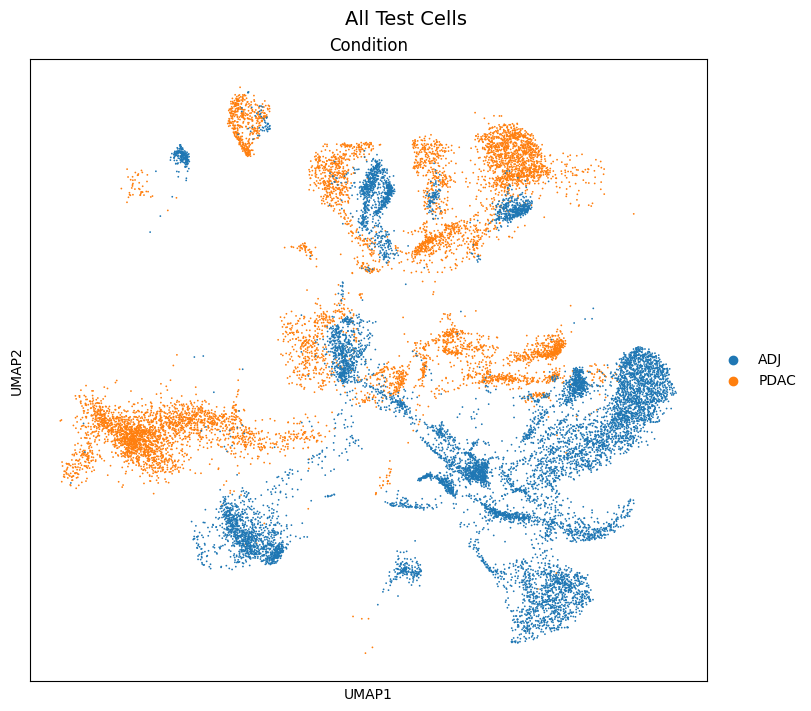

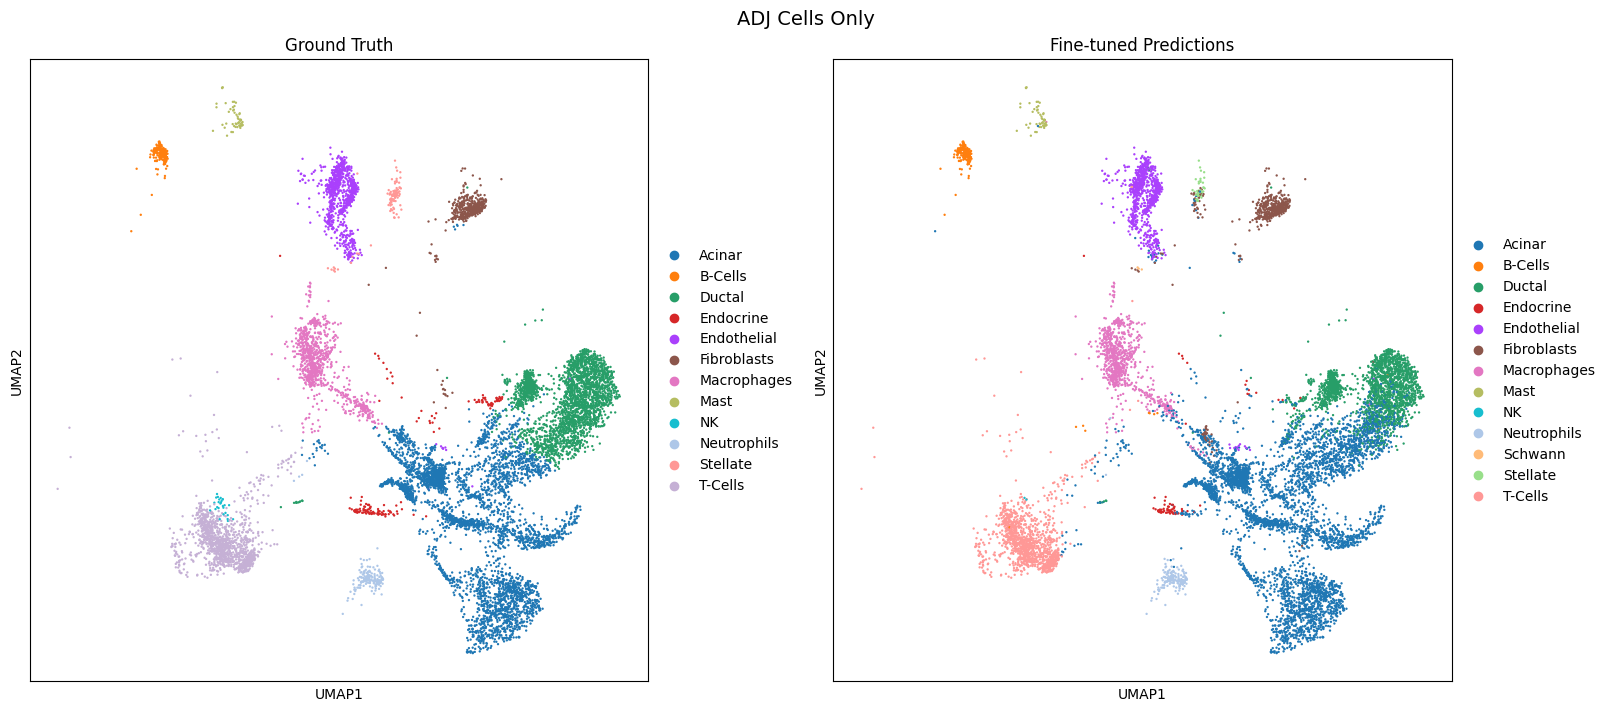

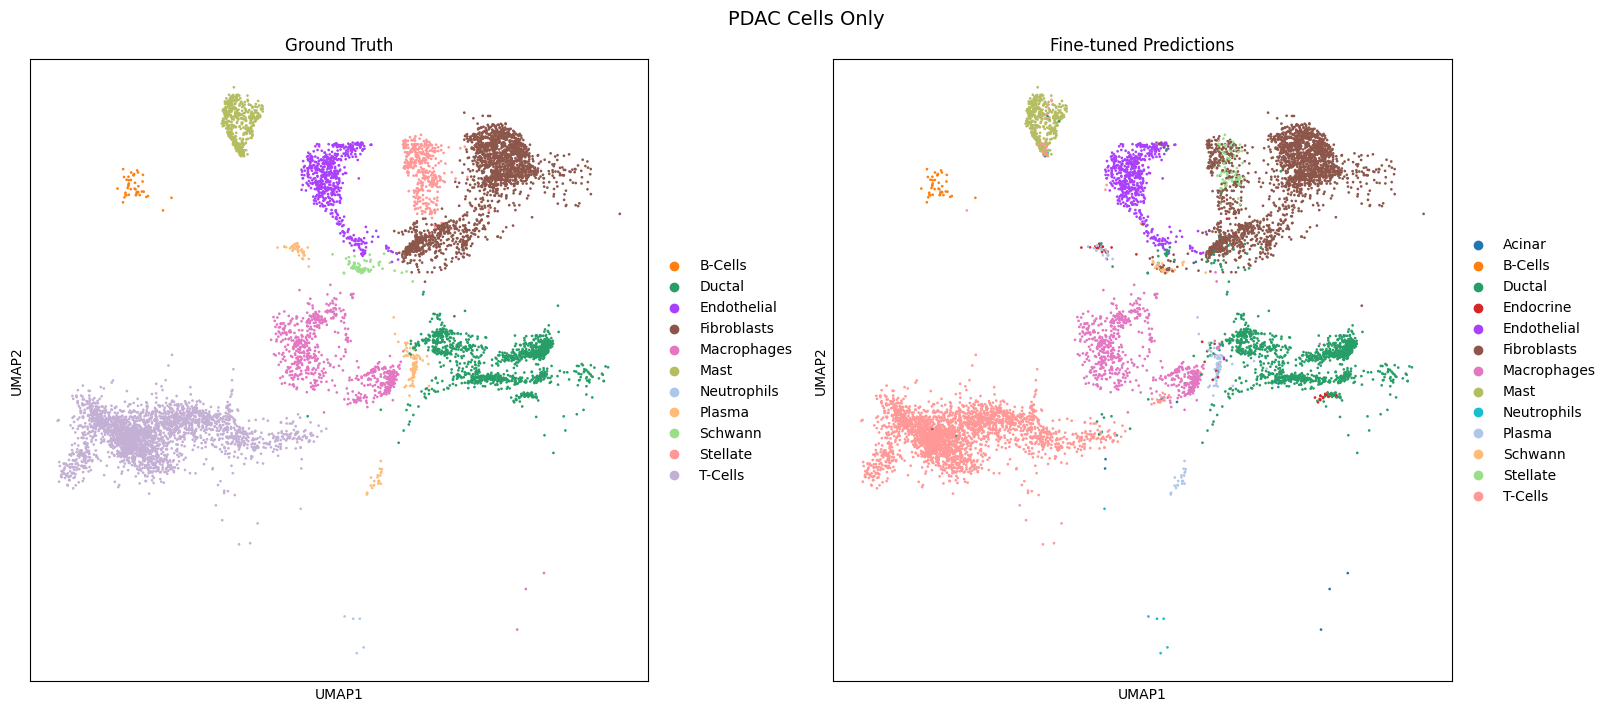

In [24]:
# Add condition + join predictions (if not already done)
adata_test.obs["condition"] = np.where(
    adata_test.obs["sample_id"].str.startswith("PDAC"),
    "PDAC",
    "ADJ",
)

pred_map = df.set_index("index")[pred_col]
adata_test.obs["scgpt_pred"] = adata_test.obs_names.map(pred_map)

# Split by condition
adata_adj = adata_test[adata_test.obs["condition"] == "ADJ"].copy()
adata_pdac = adata_test[adata_test.obs["condition"] == "PDAC"].copy()

# --- Plot 1: Combined (all test cells) ---
fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
fig.suptitle("All Test Cells", fontsize=14)

sc.pl.umap(
    adata_test,
    color="condition",
    ax=ax,
    show=False,
    title="Condition",
)

plt.show()

# --- Plot 2: ADJ only ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
fig.suptitle("ADJ Cells Only", fontsize=14)

sc.pl.umap(
    adata_adj,
    color="scGPT_target_label",
    ax=axes[0],
    show=False,
    title="Ground Truth",
)

sc.pl.umap(
    adata_adj,
    color="scgpt_pred",
    ax=axes[1],
    show=False,
    title="Fine-tuned Predictions",
)

plt.show()

# --- Plot 3: PDAC only ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
fig.suptitle("PDAC Cells Only", fontsize=14)

sc.pl.umap(
    adata_pdac,
    color="scGPT_target_label",
    ax=axes[0],
    show=False,
    title="Ground Truth",
)

sc.pl.umap(
    adata_pdac,
    color="scgpt_pred",
    ax=axes[1],
    show=False,
    title="Fine-tuned Predictions",
)

plt.show()